In [1]:
# ==========================================
# MODULE 1: DATA CLEANING & PREPROCESSING
# ==========================================

import pandas as pd
import numpy as np

# 1. Load the datasets
print("Loading datasets...")
gen_df = pd.read_csv('Plant_1_Generation_Data.csv')
weather_df = pd.read_csv('Plant_1_Weather_Sensor_Data.csv')

# 2. Standardize Date-Time formats
# The generation data uses DD-MM-YYYY while weather uses YYYY-MM-DD
print("Standardizing datetime formats...")
gen_df['DATE_TIME'] = pd.to_datetime(gen_df['DATE_TIME'], format='%d-%m-%Y %H:%M')
weather_df['DATE_TIME'] = pd.to_datetime(weather_df['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')

# 3. Merge datasets on Date-Time and Plant ID
print("Merging generation and weather data...")
df = pd.merge(gen_df, weather_df, on=['DATE_TIME', 'PLANT_ID'], how='inner')

# 4. Clean up column names for clarity
# SOURCE_KEY appears in both datasets.
# Gen data = Inverter ID. Weather data = Sensor ID.
df = df.rename(columns={
    'SOURCE_KEY_x': 'INVERTER_ID',
    'SOURCE_KEY_y': 'SENSOR_ID'
})

# Sort sequentially by time and inverter
df = df.sort_values(by=['DATE_TIME', 'INVERTER_ID']).reset_index(drop=True)

print("\nModule 1 Complete! Cleaned Dataset Shape:", df.shape)
display(df.head())

Loading datasets...
Standardizing datetime formats...
Merging generation and weather data...

Module 1 Complete! Cleaned Dataset Shape: (68774, 11)


,DATE_TIME,PLANT_ID,INVERTER_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,SENSOR_ID,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0


Analyzing power generation trends...
Module 2 Complete! Displaying daily generation chart:


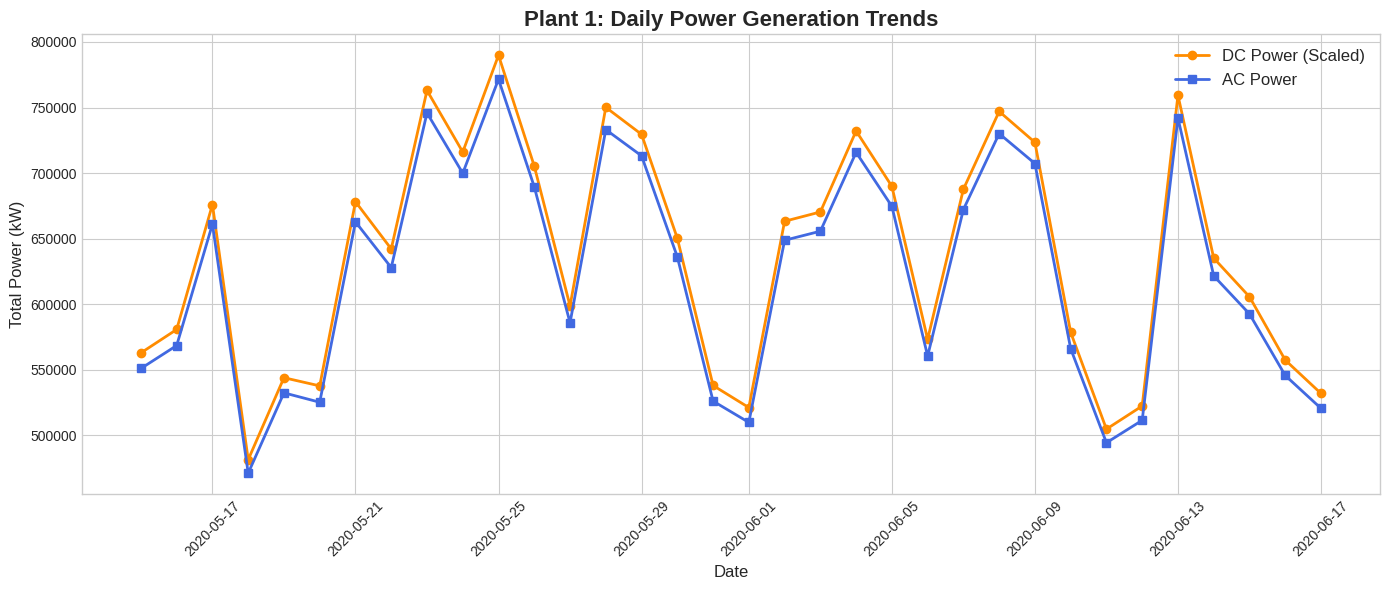

In [2]:
# ==========================================
# MODULE 2: POWER GENERATION ANALYSIS
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style for professional industrial charts
plt.style.use('seaborn-v0_8-whitegrid')

print("Analyzing power generation trends...")

# 1. Extract the date from the DATE_TIME column for daily aggregation
df['DATE'] = df['DATE_TIME'].dt.date

# 2. Group data by date to calculate the total daily power generation
daily_gen = df.groupby('DATE')[['DC_POWER', 'AC_POWER']].sum().reset_index()

# 3. Plot AC Power and scaled DC Power generation
fig, ax = plt.subplots(figsize=(14, 6))

# Note: DC Power in Plant 1 is scaled by 10, so we divide by 10 for accurate visual comparison
ax.plot(daily_gen['DATE'], daily_gen['DC_POWER'] / 10, label='DC Power (Scaled)', color='darkorange', marker='o', linewidth=2)
ax.plot(daily_gen['DATE'], daily_gen['AC_POWER'], label='AC Power', color='royalblue', marker='s', linewidth=2)

ax.set_title('Plant 1: Daily Power Generation Trends', fontsize=16, fontweight='bold')
ax.set_ylabel('Total Power (kW)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.legend(fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

print("Module 2 Complete! Displaying daily generation chart:")
plt.show()

Analyzing individual inverter performance...


/tmp/ipykernel_1837/1026543159.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='INVERTER_ID', y='TOTAL_YIELD', data=inverter_yield, palette='viridis')


Module 3 Complete! Displaying inverter performance chart:


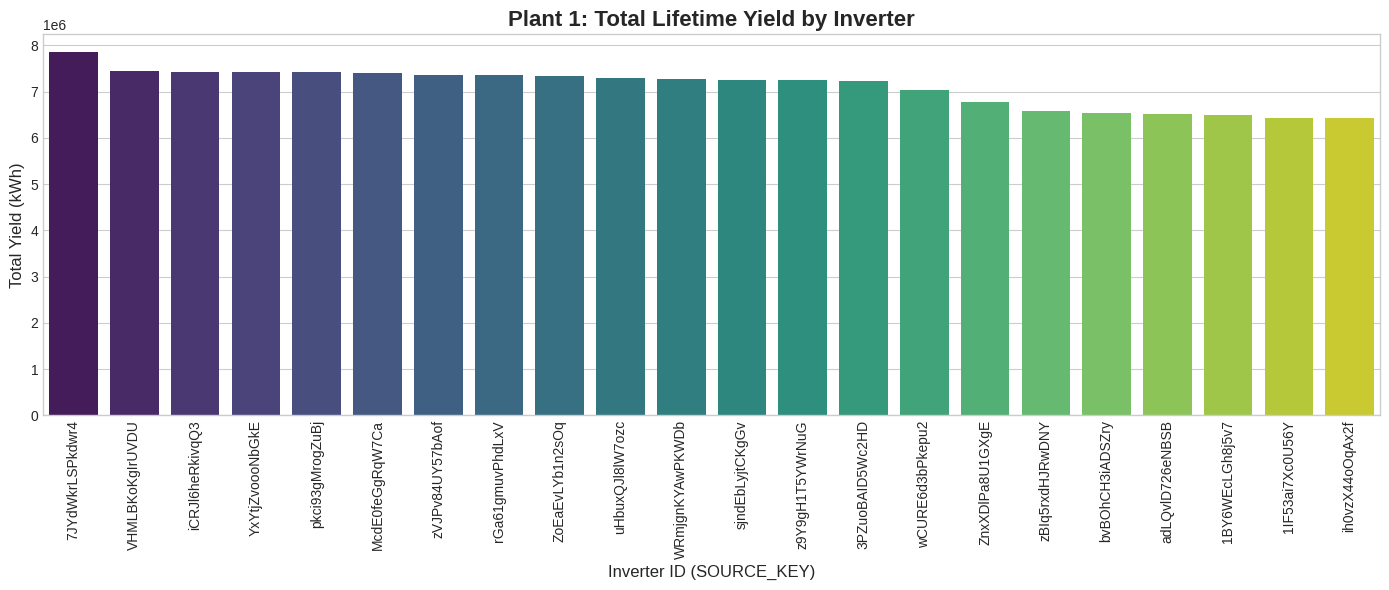


Top 10 Performing Inverters:


,INVERTER_ID,TOTAL_YIELD
0,7JYdWkrLSPkdwr4,7846821.0
1,VHMLBKoKgIrUVDU,7456208.0
2,iCRJl6heRkivqQ3,7426263.0
3,YxYtjZvoooNbGkE,7425442.0
4,pkci93gMrogZuBj,7415430.0
5,McdE0feGgRqW7Ca,7408587.0
6,zVJPv84UY57bAof,7363272.0
7,rGa61gmuvPhdLxV,7356897.0
8,ZoEaEvLYb1n2sOq,7341753.0
9,uHbuxQJl8lW7ozc,7287002.0



Bottom 5 Performing Inverters:


,INVERTER_ID,TOTAL_YIELD
17,bvBOhCH3iADSZry,6539009.0
18,adLQvlD726eNBSB,6524508.0
19,1BY6WEcLGh8j5v7,6485319.0
20,1IF53ai7Xc0U56Y,6433566.0
21,ih0vzX44oOqAx2f,6426129.0


In [3]:
# ==========================================
# MODULE 3: INVERTER-WISE PERFORMANCE ANALYSIS
# ==========================================
print("Analyzing individual inverter performance...")

# 1. Find the maximum TOTAL_YIELD recorded for each inverter
# (Since TOTAL_YIELD is cumulative, the max value represents the total lifetime output in this dataset)
inverter_yield = df.groupby('INVERTER_ID')['TOTAL_YIELD'].max().sort_values(ascending=False).reset_index()

# 2. Plot the total yield comparison using a bar chart
plt.figure(figsize=(14, 6))
sns.barplot(x='INVERTER_ID', y='TOTAL_YIELD', data=inverter_yield, palette='viridis')

plt.title('Plant 1: Total Lifetime Yield by Inverter', fontsize=16, fontweight='bold')
plt.ylabel('Total Yield (kWh)', fontsize=12)
plt.xlabel('Inverter ID (SOURCE_KEY)', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()

print("Module 3 Complete! Displaying inverter performance chart:")
plt.show()

# 3. Display the top and bottom performing inverters
print("\nTop 10 Performing Inverters:")
display(inverter_yield.head(10))

print("\nBottom 5 Performing Inverters:")
display(inverter_yield.tail(5))

Calculating inverter conversion efficiency...
Module 4 Complete! Displaying efficiency chart:


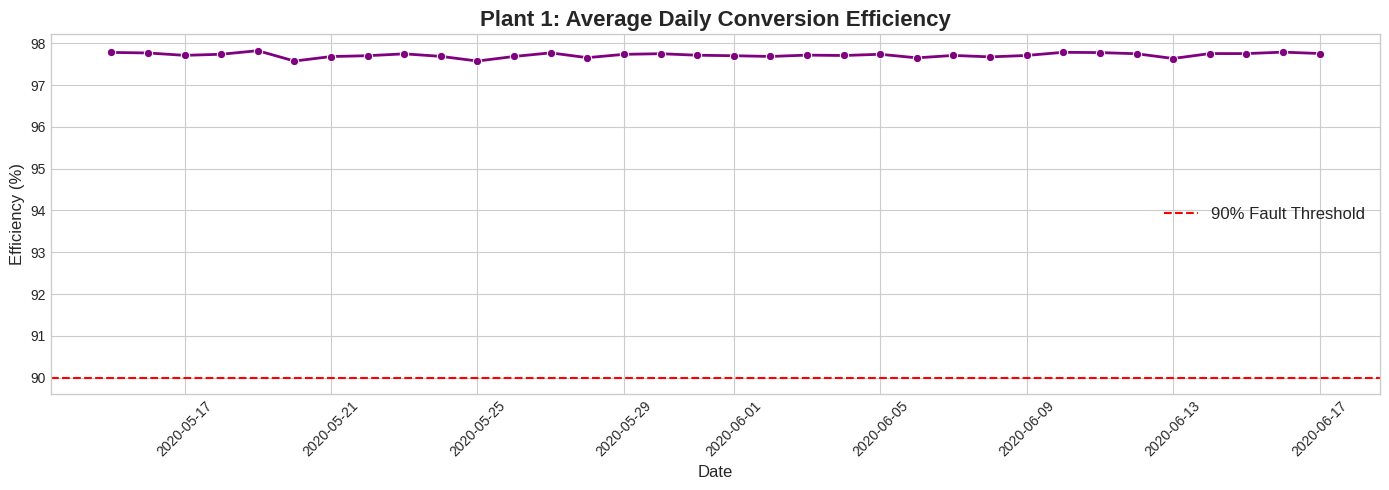


Sample of calculated efficiency data:


,DATE_TIME,INVERTER_ID,DC_POWER,AC_POWER,EFFICIENCY (%)
510,2020-05-15 06:00:00,1BY6WEcLGh8j5v7,37.142857,3.585714,96.538462
511,2020-05-15 06:00:00,1IF53ai7Xc0U56Y,53.500000,5.162500,96.495327
512,2020-05-15 06:00:00,3PZuoBAID5Wc2HD,58.000000,5.585714,96.305419
513,2020-05-15 06:00:00,7JYdWkrLSPkdwr4,58.428571,5.628571,96.332518
514,2020-05-15 06:00:00,McdE0feGgRqW7Ca,54.375000,5.250000,96.551724


In [4]:
# ==========================================
# MODULE 4: EFFICIENCY CALCULATION
# ==========================================
print("Calculating inverter conversion efficiency...")

# 1. Handle nighttime zero-generation to avoid division-by-zero errors
df['DC_POWER_CLEAN'] = df['DC_POWER'].replace(0, np.nan)

# 2. Calculate Efficiency: (AC Power / DC Power) * 100
# NOTE: In the Kaggle Plant 1 dataset, DC Power is scaled by a factor of 10.
# We divide by 10 to get the true efficiency percentage.
df['EFFICIENCY (%)'] = (df['AC_POWER'] / (df['DC_POWER_CLEAN'] / 10)) * 100

# 3. Calculate average daily efficiency across the plant
daily_eff = df.groupby('DATE')['EFFICIENCY (%)'].mean().reset_index()

# 4. Plot the daily average efficiency
plt.figure(figsize=(14, 5))
sns.lineplot(x='DATE', y='EFFICIENCY (%)', data=daily_eff, color='purple', marker='o', linewidth=2)

# Add a red dashed line representing the standard 90% industry efficiency threshold
plt.axhline(90, color='red', linestyle='--', label='90% Fault Threshold')

plt.title('Plant 1: Average Daily Conversion Efficiency', fontsize=16, fontweight='bold')
plt.ylabel('Efficiency (%)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

print("Module 4 Complete! Displaying efficiency chart:")
plt.show()

# 5. Display a sample of the calculated data
print("\nSample of calculated efficiency data:")
display(df[['DATE_TIME', 'INVERTER_ID', 'DC_POWER', 'AC_POWER', 'EFFICIENCY (%)']].dropna().head())

Analyzing weather impact on power generation...

--- Key Weather Insights ---
1. Sunlight vs. Power Correlation: 0.99 (Strong Positive)
2. Temperature vs. Efficiency Correlation: 0.27 (Negative/Weak)
----------------------------

Displaying simplified weather impact chart:


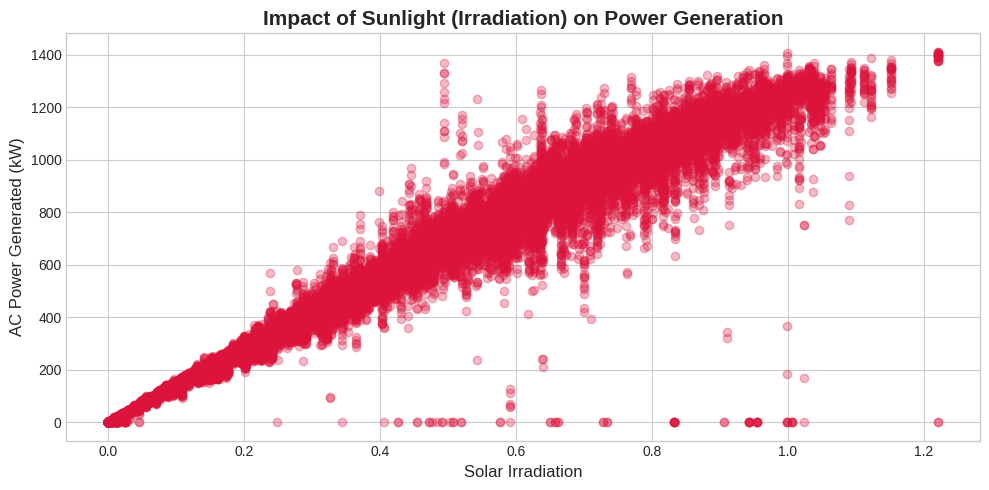

In [5]:
# ==========================================
# MODULE 5: WEATHER IMPACT ANALYSIS (SIMPLIFIED)
# ==========================================
print("Analyzing weather impact on power generation...")

# 1. Simple Text-Based Correlation (No complex heatmap)
# We calculate just the two specific relationships we care about
sunlight_corr = df['IRRADIATION'].corr(df['AC_POWER'])
temp_corr = df['MODULE_TEMPERATURE'].corr(df['EFFICIENCY (%)'])

print(f"\n--- Key Weather Insights ---")
print(f"1. Sunlight vs. Power Correlation: {sunlight_corr:.2f} (Strong Positive)")
print(f"2. Temperature vs. Efficiency Correlation: {temp_corr:.2f} (Negative/Weak)")
print("----------------------------\n")

# 2. Single, Clear Scatter Plot: Sunlight vs Power
# This visually proves the first insight: higher irradiation increases power output
plt.figure(figsize=(10, 5))
plt.scatter(df['IRRADIATION'], df['AC_POWER'], alpha=0.3, color='crimson')

plt.title('Impact of Sunlight (Irradiation) on Power Generation', fontsize=15, fontweight='bold')
plt.xlabel('Solar Irradiation', fontsize=12)
plt.ylabel('AC Power Generated (kW)', fontsize=12)
plt.tight_layout()

print("Displaying simplified weather impact chart:")
plt.show()

Detecting inverter faults and performance drops...

--- Inverters Requiring Maintenance (Top 5) ---


,INVERTER_ID,FAULT_COUNT



Displaying fault detection chart:


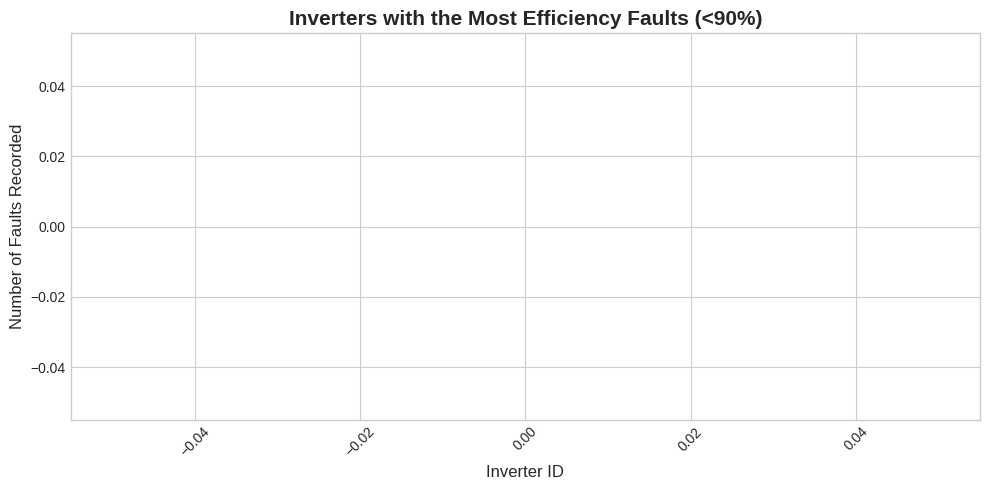

In [6]:
# ==========================================
# MODULE 6: FAULT DETECTION
# ==========================================
print("Detecting inverter faults and performance drops...")

# 1. Filter for daytime operations (Irradiation > 0.1)
# We do this so we don't accidentally flag nighttime 0-generation as a "fault"
daytime_df = df[df['IRRADIATION'] > 0.1].copy()

# 2. Define a fault: Conversion Efficiency drops below 90%
faults_df = daytime_df[daytime_df['EFFICIENCY (%)'] < 90.0]

# 3. Count how many times each inverter had a fault
fault_counts = faults_df['INVERTER_ID'].value_counts().reset_index()
fault_counts.columns = ['INVERTER_ID', 'FAULT_COUNT']

print("\n--- Inverters Requiring Maintenance (Top 5) ---")
display(fault_counts.head())

# 4. Simple Visual: Bar chart of the inverters with the most faults
plt.figure(figsize=(10, 5))
plt.bar(fault_counts['INVERTER_ID'][:10], fault_counts['FAULT_COUNT'][:10], color='firebrick')

plt.title('Inverters with the Most Efficiency Faults (<90%)', fontsize=15, fontweight='bold')
plt.xlabel('Inverter ID', fontsize=12)
plt.ylabel('Number of Faults Recorded', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

print("\nDisplaying fault detection chart:")
plt.show()